In [1]:
import csv
import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn import linear_model

In [6]:
import random

class MySGDRegression:
    def __init__(self):
        self.intercept_ = 0.0
        self.coef_ = []


    def fitBatch(self, x, y, learningRate = 0.001, noEpochs = 1000):
        self.coef_ = [0.0 for _ in range(len(x[0]) + 1)]    #w coefficients y = w0 + w1 * x1 + w2 * x2 + ...
        m = len(x)
        for epoch in range(noEpochs):
            for j in range(0, len(x[0])):
                sumGrad = 0
                for i in range(m):
                    ycomputed = self.eval(x[i])
                    crtError = ycomputed - y[i]
                    sumGrad += crtError * x[i][j]
                self.coef_[j] = self.coef_[j] - learningRate * sumGrad / m
            sumGrad = 0
            #acelasi lucru ca mai sus dar pentru w0
            #Bias-ul nu depinde de un anumit feature, ci afectează toate predicțiile uniform.
            #Așa că nu-l actualizezi în buclă pentru fiecare caracteristică individuală, ci după ce ai calculat eroarea cumulată pe întregul batch de date.
            #Weight-urile: cât de mult afectează fiecare feature predicția mea
            #Bias-ul: cât de mult deplasez linia de predicție în sus sau jos
            for i in range(m):
                ycomputed = self.eval(x[i])
                crtError = ycomputed - y[i]
                sumGrad += crtError
            self.coef_[len(x[0])] = self.coef_[len(x[0])] - learningRate * sumGrad / m

        self.intercept_ = self.coef_[-1]
        self.coef_ = self.coef_[:-1]

    def eval(self, xi):
        yi = self.coef_[-1]
        for j in range(len(xi)):
            yi += self.coef_[j] * xi[j]
        return yi 

    def predict(self, x):
        yComputed = [self.eval(xi) for xi in x]
        return yComputed

In [7]:
def loadData(fileName, inputVariabName, outputVariabName):
    data = []
    dataNames = []
    with open(fileName) as csv_file:
        csv_reader = csv.reader(csv_file, delimiter=',')
        line_count = 0
        for row in csv_reader:
            if line_count == 0:
                dataNames = row
            else:
                data.append(row)
            line_count += 1
    selectedVariable = dataNames.index(inputVariabName)
    inputs = [float(data[i][selectedVariable]) for i in range(len(data))]
    selectedOutput = dataNames.index(outputVariabName)
    outputs = [float(data[i][selectedOutput]) for i in range(len(data))]
    
    return inputs, outputs

crtDir =  os.getcwd()
filePath = 'v1_world-happiness-report-2017.csv'

inputs, outputs = loadData(filePath, 'Economy..GDP.per.Capita.', 'Happiness.Score')
print('in:  ', inputs[:5])
print('out: ', outputs[:5])

in:   [1.616463184, 1.482383013, 1.48063302, 1.564979553, 1.443571925]
out:  [7.537000179, 7.521999836, 7.504000187, 7.493999958, 7.468999863]


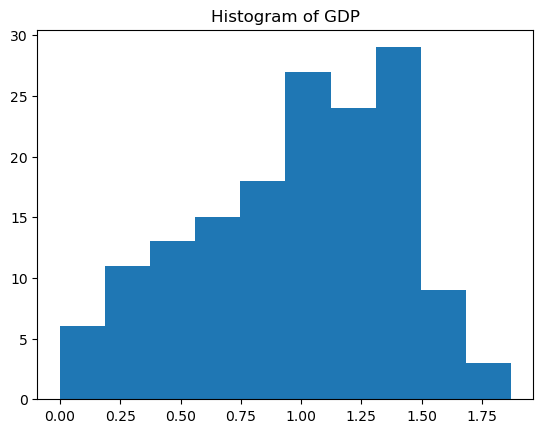

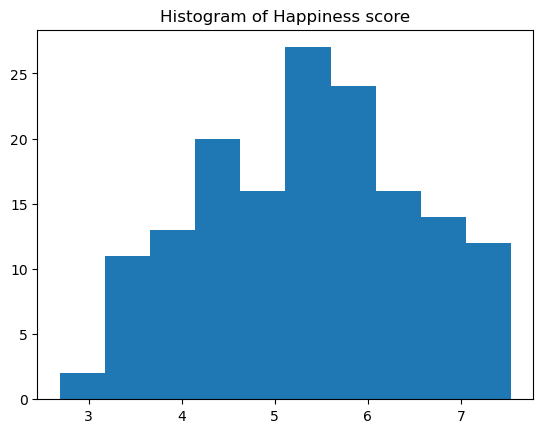

In [8]:

def plotDataHistogram(x, variableName):
    n, bins, patches = plt.hist(x, 10)
    plt.title('Histogram of ' + variableName)
    plt.show()

plotDataHistogram(inputs, 'GDP')
plotDataHistogram(outputs, 'Happiness score')

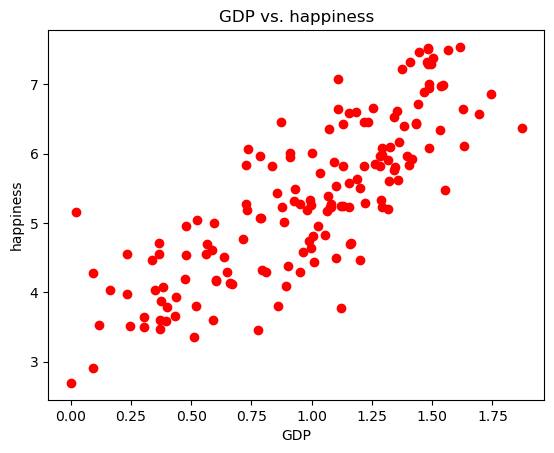

In [9]:
plt.plot(inputs, outputs, 'ro') 
plt.xlabel('GDP')
plt.ylabel('happiness')
plt.title('GDP vs. happiness')
plt.show()

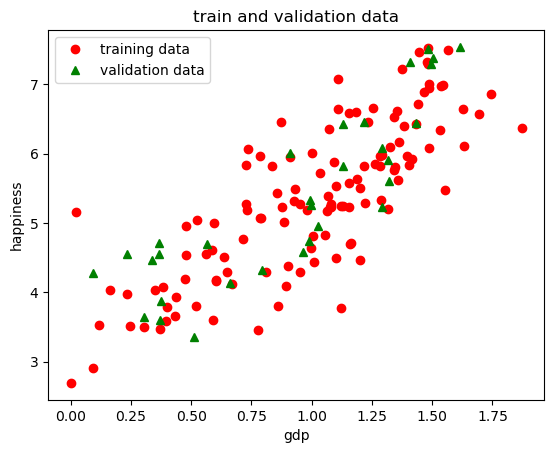

In [10]:

np.random.seed(5)
indexes = [i for i in range(len(inputs))]
trainSample = np.random.choice(indexes, int(0.8 * len(inputs)), replace = False)
validationSample = [i for i in indexes  if not i in trainSample]

trainInputs = [inputs[i] for i in trainSample]
trainOutputs = [outputs[i] for i in trainSample]

validationInputs = [inputs[i] for i in validationSample]
validationOutputs = [outputs[i] for i in validationSample]

plt.plot(trainInputs, trainOutputs, 'ro', label = 'training data')   #train data are plotted by red and circle sign
plt.plot(validationInputs, validationOutputs, 'g^', label = 'validation data')     #test data are plotted by green and a triangle sign
plt.title('train and validation data')
plt.xlabel('gdp')
plt.ylabel('happiness')
plt.legend()
plt.show()

In [ ]:
TOOL

In [11]:
from sklearn.linear_model import SGDRegressor

xx = [[el] for el in trainInputs]
regressor = SGDRegressor()
regressor.fit(xx, trainOutputs)
w0, w1 = regressor.intercept_, regressor.coef_[0]
print('the learnt model: f(x) = ', w0, ' + ', w1, ' * x')

the learnt model: f(x) =  [2.72048312]  +  2.5987425572934737  * x


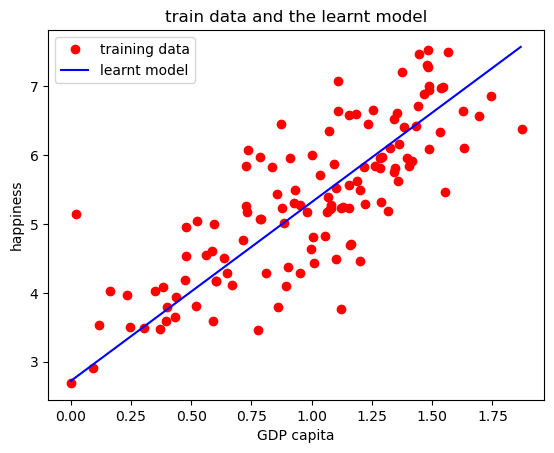

In [12]:
noOfPoints = 1000
xref = []
val = min(trainInputs)
step = (max(trainInputs) - min(trainInputs)) / noOfPoints
for i in range(1, noOfPoints):
    xref.append(val)
    val += step
yref = regressor.predict([[xval] for xval in xref])

plt.plot(trainInputs, trainOutputs, 'ro', label = 'training data')  #train data are plotted by red and circle sign
plt.plot(xref, yref, 'b-', label = 'learnt model')                  #model is plotted by a blue line
plt.title('train data and the learnt model')
plt.xlabel('GDP capita')
plt.ylabel('happiness')
plt.legend()
plt.show()

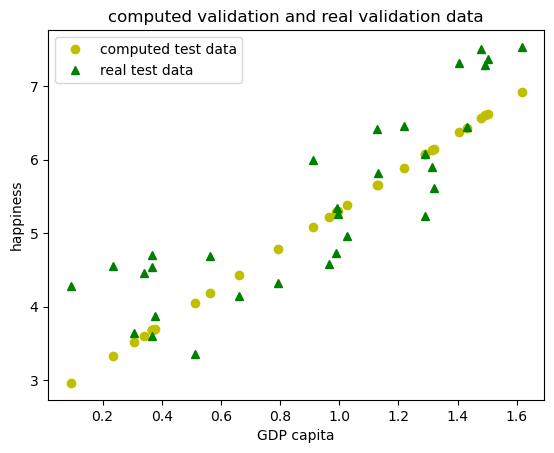

In [14]:
computedValidationOutputs = regressor.predict([[x] for x in validationInputs])

plt.plot(validationInputs, computedValidationOutputs, 'yo', label = 'computed test data')  #computed test data are plotted yellow red and circle sign
plt.plot(validationInputs, validationOutputs, 'g^', label = 'real test data')  #real test data are plotted by green triangles
plt.title('computed validation and real validation data')
plt.xlabel('GDP capita')
plt.ylabel('happiness')
plt.legend()
plt.show()

In [15]:
error = 0.0
for t1, t2 in zip(computedValidationOutputs, validationOutputs):
    error += (t1 - t2) ** 2
error = error / len(validationOutputs)
print('prediction error (manual): ', error)

# by using sklearn 
from sklearn.metrics import mean_squared_error

error = mean_squared_error(validationOutputs, computedValidationOutputs)
print('prediction error (tool):  ', error)

prediction error (manual):  0.44639370030540315
prediction error (tool):   0.44639370030540315


In [ ]:
IMPLEMENTARE PROPRIE

the learnt model: f(x) =  [2.72048312]  +  2.5987425572934737  * x


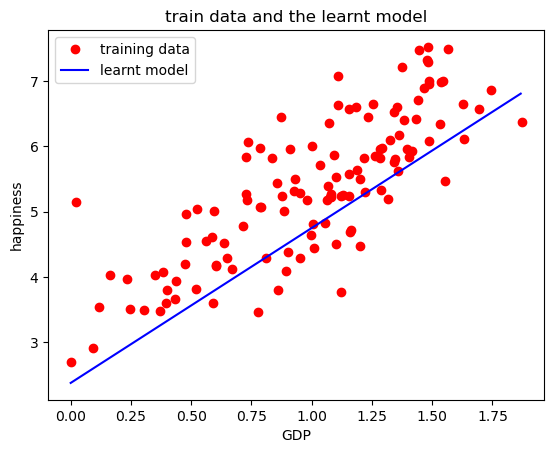

In [16]:
myRegressor=MySGDRegression()
myRegressor.fitBatch(xx, trainOutputs)
w0,w1=regressor.intercept_,regressor.coef_[0]
print('the learnt model: f(x) = ', w0, ' + ', w1, ' * x')

noOfPoints = 1000
xref = []
val = min(trainInputs)
step = (max(trainInputs) - min(trainInputs)) / noOfPoints
for i in range(1, noOfPoints):
    xref.append(val)
    val += step
yref = myRegressor.predict([[xval] for xval in xref])

plt.plot(trainInputs, trainOutputs, 'ro', label='training data')
plt.plot(xref, yref, 'b-', label='learnt model')
plt.title('train data and the learnt model')
plt.xlabel('GDP')
plt.ylabel('happiness')
plt.legend()
plt.show()


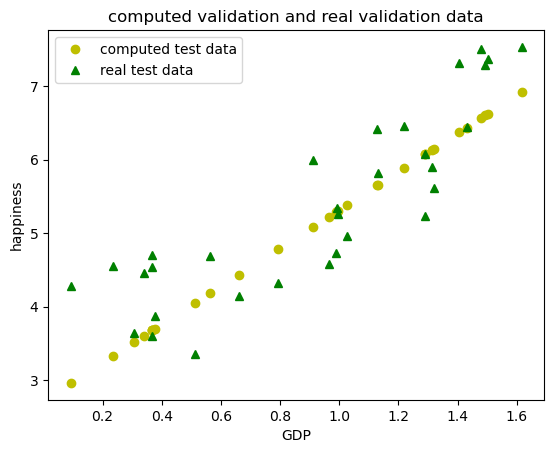

In [17]:
computed_validation_outputs = regressor.predict([[x] for x in validationInputs])

plt.plot(validationInputs, computed_validation_outputs, 'yo', label='computed test data')
plt.plot(validationInputs, validationOutputs, 'g^', label='real test data')
plt.title('computed validation and real validation data')
plt.xlabel('GDP')
plt.ylabel('happiness')
plt.legend()
plt.show()

In [18]:
error = 0.0
for t1, t2 in zip(computedValidationOutputs, validationOutputs):
    error += (t1 - t2) ** 2
error = error / len(validationOutputs)
print('prediction error (manual): ', error)

# by using sklearn 
from sklearn.metrics import mean_squared_error

error = mean_squared_error(validationOutputs, computedValidationOutputs)
print('prediction error (tool):  ', error)

prediction error (manual):  0.44639370030540315
prediction error (tool):   0.44639370030540315


In [ ]:
 Produsul intern brut si de gradul de libertate.

In [21]:
def loadData2(fileName, inputVariabName1,inputVariabName2, outputVariabName):
    data = []
    dataNames = []
    with open(fileName) as csv_file:
        csv_reader = csv.reader(csv_file, delimiter=',')
        line_count = 0
        for row in csv_reader:
            if line_count == 0:
                dataNames = row
            else:
                data.append(row)
            line_count += 1
    selectedVariable1 = dataNames.index(inputVariabName1)
    inputs1 = [float(data[i][selectedVariable1]) for i in range(len(data))]
    selectedVariable2 = dataNames.index(inputVariabName2)
    inputs2 = [float(data[i][selectedVariable2]) for i in range(len(data))]
    selectedOutput = dataNames.index(outputVariabName)
    outputs = [float(data[i][selectedOutput]) for i in range(len(data))]
    
    return inputs1,inputs2, outputs

in1:   [1.616463184, 1.482383013, 1.48063302, 1.564979553, 1.443571925]
in2:  [0.635422587, 0.626006722, 0.627162635, 0.620070577, 0.617950857]
out:  [7.537000179, 7.521999836, 7.504000187, 7.493999958, 7.468999863]


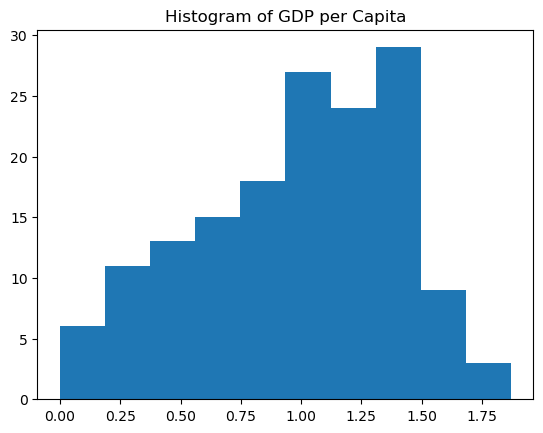

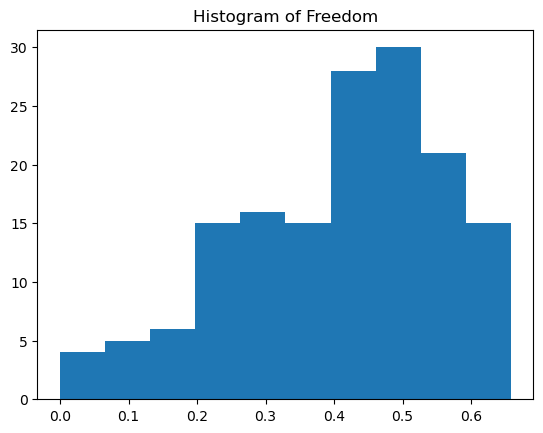

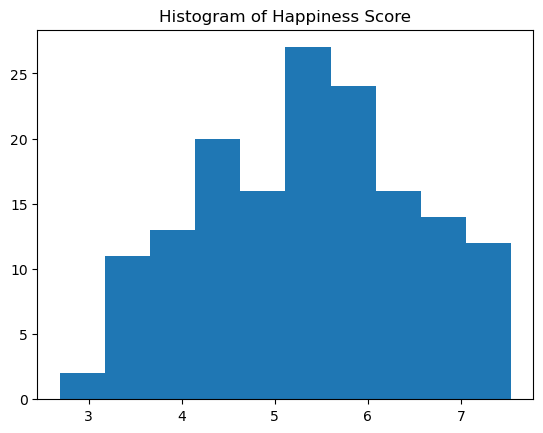

In [22]:
crtDir =  os.getcwd()
filePath = 'v1_world-happiness-report-2017.csv'

inputs1,inputs2, outputs = loadData2(filePath, 'Economy..GDP.per.Capita.','Freedom', 'Happiness.Score')
print('in1:  ', inputs1[:5])
print('in2: ',inputs2[:5])
print('out: ', outputs[:5])


plotDataHistogram(inputs1, 'GDP per Capita')
plotDataHistogram(inputs2, 'Freedom')
plotDataHistogram(outputs, 'Happiness Score')


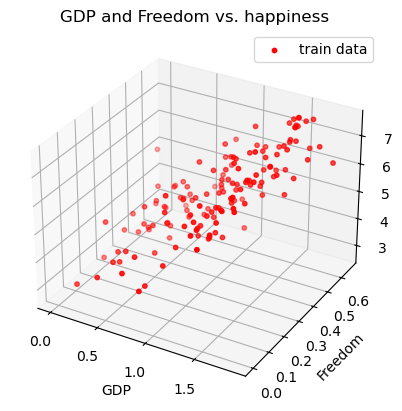

In [23]:
def plot3Ddata(x1_train, x2_train, y_train, x1_model=None, x2_model=None, y_model=None, x1_test=None, x2_test=None,
               y_test=None,
               title=None):
    ax = plt.axes(projection='3d')
    if x1_train is not None and len(x1_train)>0:
        ax.scatter(x1_train, x2_train, y_train, c='r', marker='o', label='train data', s=10)
    if x1_model is not None and len(x1_model)>0:
        ax.scatter(x1_model, x2_model, y_model, c='g', marker='_', label='learnt model')
    if x1_test is not None and len(x1_test)>0:
        ax.scatter(x1_test, x2_test, y_test, c='pink', marker='^', label='test data')
    plt.title(title)
    ax.set_xlabel("GDP")
    ax.set_ylabel("Freedom")
    ax.set_zlabel("Happiness")
    plt.legend()
    plt.show()


#Check linearity
plot3Ddata(inputs1,inputs2,outputs,[],[],[],[],[],[],"GDP and Freedom vs. happiness")


In [24]:
def normalisation(trainData, testData):
    #MinMax Scalling
    length = len(trainData)
    for i in range(length):
        minimum = np.min(trainData)
        maximum = np.max(trainData)
        trainData[i] = (trainData[i] - minimum) / (maximum - minimum)

    length = len(testData)
    for i in range(length):
        minimum = np.min(testData)
        maximum = np.max(testData)
        testData[i] = (testData[i] - minimum) / (maximum - minimum)

    return trainData, testData

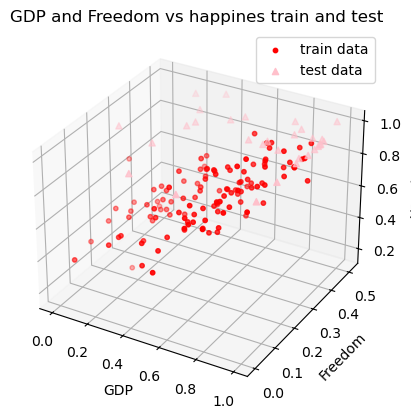

In [25]:
X=np.column_stack((inputs1,inputs2))



# split data into training data (80%) and testing data (20%)
np.random.seed(5)
indexes = [i for i in range(len(inputs1))]
trainSample = np.random.choice(indexes, int(0.8 * len(inputs)), replace = False)
validationSample = [i for i in indexes  if not i in trainSample]
trainInputs = X[trainSample]
trainOutputs = [outputs[i] for i in trainSample]
validationInputs = X[validationSample]
validationOutputs = [outputs[i] for i in validationSample]

trainInputs, validationInputs = normalisation(trainInputs, validationInputs)
trainOutputs, validationOutputs = normalisation(trainOutputs, validationOutputs)

plot3Ddata(trainInputs[:,0],trainInputs[:,1],trainOutputs,[],[],[],validationInputs[:,0],validationInputs[:,1],validationOutputs,"GDP and Freedom vs happines train and test")


In [ ]:
TOOL

In [26]:
from sklearn.linear_model import SGDRegressor

regressor = SGDRegressor()
regressor.fit(trainInputs, trainOutputs)
w0, w1, w2 = regressor.intercept_, regressor.coef_[0], regressor.coef_[1]
w0 = w0[0]
print('the learnt model (sklearn): f(x) = ', w0, ' + ', w1, ' * x1 + ', w2, ' * x2')

the learnt model (sklearn): f(x) =  0.5019175690889456  +  0.32935644040455553  * x1 +  0.12842819654715046  * x2


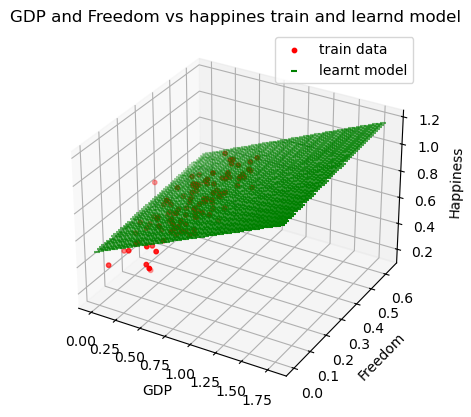

In [27]:
noOfPoints=50
x1ref = []
val = min(inputs1)
step = (max(inputs1) - min(inputs1)) / noOfPoints
for i in range(1, noOfPoints):
    x1ref.append(val)
    val += step
x2ref = []
val = min(inputs2)
step = (max(inputs2) - min(inputs2)) / noOfPoints
for i in range(1, noOfPoints):
    x2ref.append(val)
    val += step

X1,X2=np.meshgrid(x1ref,x2ref)
Y=w0+w1*X1+w2*X2

plot3Ddata(trainInputs[:,0],trainInputs[:,1],trainOutputs,X1,X2,Y,[],[],[],"GDP and Freedom vs happines train and learnd model")


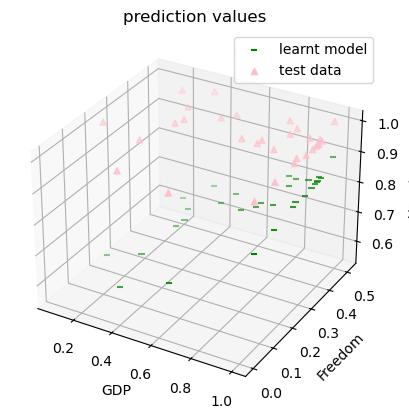

prediction error (manual):  0.056335642202004384
prediction error (tool):   0.056335642202004384


In [28]:
computedValidationOutputs=regressor.predict(validationInputs)
plot3Ddata([],[],[],validationInputs[:,0],validationInputs[:,1],computedValidationOutputs,validationInputs[:,0],validationInputs[:,1],validationOutputs,"prediction values")


error = 0.0
for t1, t2 in zip(computedValidationOutputs, validationOutputs):
    error += (t1 - t2) ** 2
error = error / len(validationOutputs)
print('prediction error (manual): ', error)

from sklearn.metrics import mean_squared_error

error = mean_squared_error(validationOutputs, computedValidationOutputs)
print('prediction error (tool):  ', error)

In [ ]:
IMPLEMENTARE PROPRIE

the learnt model: f(x) =  [0.50191757]  +  0.32935644040455553  * x 0.12842819654715046  * x2


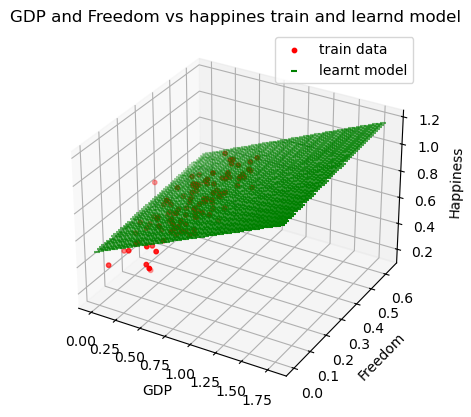

In [31]:
myRegressor=MySGDRegression()
myRegressor.fitBatch(trainInputs, trainOutputs)
w0,w1,w2=regressor.intercept_,regressor.coef_[0],regressor.coef_[1]
print('the learnt model: f(x) = ', w0, ' + ', w1, ' * x', w2, ' * x2')

noOfPoints=50
x1ref = []
val = min(inputs1)
step = (max(inputs1) - min(inputs1)) / noOfPoints
for i in range(1, noOfPoints):
    x1ref.append(val)
    val += step
x2ref = []
val = min(inputs2)
step = (max(inputs2) - min(inputs2)) / noOfPoints
for i in range(1, noOfPoints):
    x2ref.append(val)
    val += step

X1,X2=np.meshgrid(x1ref,x2ref)
Y=w0+w1*X1+w2*X2

plot3Ddata(trainInputs[:,0],trainInputs[:,1],trainOutputs,X1,X2,Y,[],[],[],"GDP and Freedom vs happines train and learnd model")


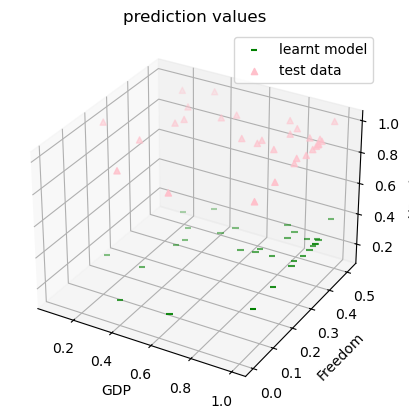

prediction error (manual):  0.4966583353445497
prediction error (tool):   0.4966583353445497


In [33]:
computedValidationOutputs=myRegressor.predict(validationInputs)
plot3Ddata([],[],[],validationInputs[:,0],validationInputs[:,1],computedValidationOutputs,validationInputs[:,0],validationInputs[:,1],validationOutputs,"prediction values")


error = 0.0
for t1, t2 in zip(computedValidationOutputs, validationOutputs):
    error += (t1 - t2) ** 2
error = error / len(validationOutputs)
print('prediction error (manual): ', error)

# by using sklearn 
from sklearn.metrics import mean_squared_error

error = mean_squared_error(validationOutputs, computedValidationOutputs)
print('prediction error (tool):  ', error)